
<a href="https://colab.research.google.com/github/kokchun/Databehandling-AI22/blob/main/Exercises/E01_missing_aggregation.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Missing data and aggregations exercises

---
These are introductory exercises in Pandas with focus in **syntax, indexing, data selection, missing data, aggregations, visualizations** and **data cleaning**.

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that there are usually many ways to achieve same results using operations in pandas. Feel free to investigate several ways. </p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to format your input questions in a pedagogical way to guide the user

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 1. Find missing values (*)

&nbsp; a) Read in the file "student-mat-missing-data.csv" found in the course github repo into a Pandas DataFrame

&nbsp; b) Do some initial explorations with the methods to get an understanding of the dataset:
```py
head(), info(), describe(), value_counts(), unique(), columns()
```

&nbsp; c) Create a function that takes in a DataFrame as input parameter and plots a barplot with the columns that have missing values. Put this function into a file called data_utils.py.
When you come across more useful functions, you can store them in your data_utils module. 

&nbsp; d) Now import your function from the module data_utils and use it to visualize NaNs in your dataset.

&nbsp; e) Find all rows where the freetime is NaN.   

&nbsp; f) Find all rows where the freetime **or** the age is NaN.  

&nbsp; g) You will notice that some rows have several NaNs. Now compute the proportion that these rows constitute of the whole dataset.

<details>
<summary>Hint</summary>

&nbsp; c) Use 
```py
isnull()
```
in combination with aggregation functions such as 
```py
sum()
```

Use seaborn to plot

f) use bitwise or: | 


</details>

<br/>

<details>

<summary>Answer</summary>

d)

![null values graph](../assets/null_vals_student.png)

e) 

These row indices: 
[87, 99, 130, 149, 151, 160, 191, 257, 276, 293, 308, 330, 343, 359, 372, 385]
 
f) 

These row indices:
[20,  71,  87,  99, 102, 106, 121, 130, 149, 151, 160, 188, 191, 214, 257, 270, 276, 293, 308, 330, 343, 348, 359, 372, 385]

g) 

These rows constitutes 0.0127 of the dataset

h)

![null values graph after cleaned once](../assets/null_vals_student_2.png)

</details>

In [60]:
# Uppgift 1A och 1B

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

data_path = Path("..") /"Data/student-mat-missing-data.csv"

df = pd.read_csv(data_path)
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  395 non-null    int64  
 1   school      395 non-null    object 
 2   sex         395 non-null    object 
 3   age         381 non-null    float64
 4   address     390 non-null    object 
 5   famsize     395 non-null    object 
 6   Pstatus     395 non-null    object 
 7   Medu        395 non-null    int64  
 8   Fedu        395 non-null    int64  
 9   Mjob        395 non-null    object 
 10  Fjob        395 non-null    object 
 11  reason      395 non-null    object 
 12  guardian    395 non-null    object 
 13  traveltime  395 non-null    int64  
 14  studytime   395 non-null    int64  
 15  failures    395 non-null    int64  
 16  schoolsup   395 non-null    object 
 17  famsup      395 non-null    object 
 18  paid        395 non-null    object 
 19  activities  395 non-null    o

c:\Users\adamh\Git\Databehandling-Adam-Hedlund\Exercises\data_utils.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = missing_df, x="Kolumn", y="Antal saknade värden", palette="magma")


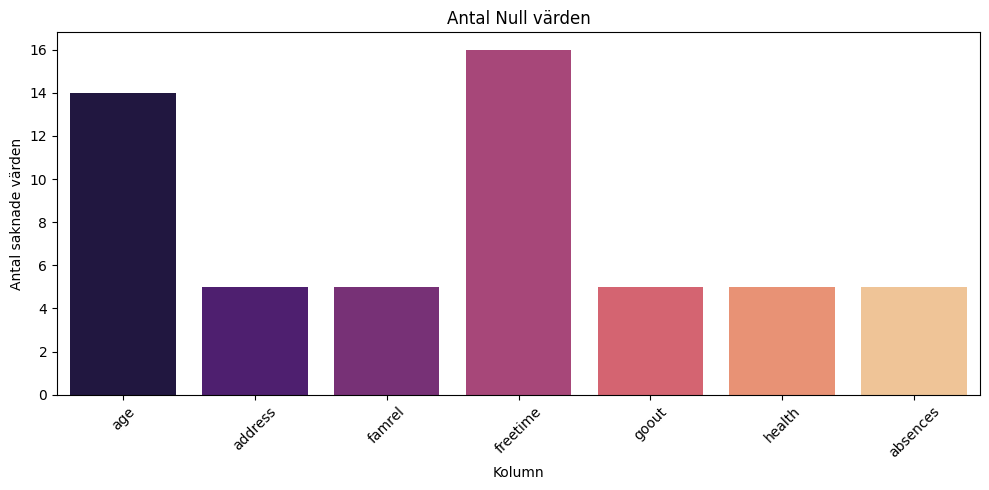

In [61]:
#Uppgift 1D
from data_utils import plot_missing_values

plot_missing_values(df)

In [62]:
#Uppgift 1E

nan_rows = df[df["freetime"].isnull()]
print(nan_rows)

     Unnamed: 0 school sex   age address famsize Pstatus  Medu  Fedu  \
87           87     GP   F  15.0       U     GT3       T     4     2   
99           99     GP   F  16.0       U     GT3       T     4     3   
130         130     GP   F  15.0       R     GT3       T     3     4   
149         149     GP   M  15.0       U     LE3       A     2     1   
151         151     GP   M  16.0       U     LE3       T     2     1   
160         160     GP   M   NaN     NaN     LE3       T     2     1   
191         191     GP   F   NaN     NaN     GT3       T     1     1   
257         257     GP   M  19.0       U     LE3       A     4     3   
276         276     GP   F   NaN     NaN     GT3       A     3     2   
293         293     GP   F   NaN     NaN     LE3       T     3     1   
308         308     GP   M  19.0       R     GT3       T     3     3   
330         330     GP   M  18.0       U     LE3       T     2     2   
343         343     GP   F  17.0       U     GT3       A     2  

In [63]:
#Uppgift 1F
nan_rows1 = df[df["freetime"].isnull() | df["age"].isnull()]
print(nan_rows1)

     Unnamed: 0 school sex   age address famsize Pstatus  Medu  Fedu  \
20           20     GP   M   NaN       U     GT3       T     4     3   
71           71     GP   M   NaN       U     GT3       T     4     2   
87           87     GP   F  15.0       U     GT3       T     4     2   
99           99     GP   F  16.0       U     GT3       T     4     3   
102         102     GP   M   NaN       U     GT3       T     4     4   
106         106     GP   F   NaN       U     GT3       T     2     2   
121         121     GP   M   NaN       U     GT3       T     2     2   
130         130     GP   F  15.0       R     GT3       T     3     4   
149         149     GP   M  15.0       U     LE3       A     2     1   
151         151     GP   M  16.0       U     LE3       T     2     1   
160         160     GP   M   NaN     NaN     LE3       T     2     1   
188         188     GP   F   NaN       U     GT3       A     3     3   
191         191     GP   F   NaN     NaN     GT3       T     1  

In [64]:
#Uppgift 1G
rows_with_multiple_nan = df[df.isnull().sum(axis=1) > 1]
numbers_multiple_nan = len(rows_with_multiple_nan)
df_total = len(df)
diff_nan = numbers_multiple_nan / df_total
print(f"{diff_nan:.4f}")


0.0127


---
## 2. Clean the data (*)

&nbsp; a) As you have conversed with a domain expert you both agree that there are too many missing data to fill in and the proportion is small enough to be safe to just remove.  
Now remove these rows and use your missing-value utility function visualize the remaining NaNs.

&nbsp; b) The domain expert has told you that you have to fill in the missing age values.
Start with visualising the age distribution in the dataset using a histogram. 

&nbsp; c) Check which columns there are in the dataset to see what can be utilised in determining the age.

&nbsp; d) The column higher seems interesting. Let's see which unique values it can have. 

&nbsp; e) Let's see if we can see some connection between age distribution and higher.
Make 3 subplots of age histograms:
- Plot 1: same as b)
- Plot 2: age distribution when higher is yes 
- Plot 3: age distribution when higher is no  

&nbsp; f) That was hard to find a connection. When reading [dataset source](https://www.kaggle.com/uciml/student-alcohol-consumption) we find alcohol consumption, maybe there is some connection between age and alcohol consumption.
- Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
- Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)

&nbsp; Start with creating a new column called Alcohol, which is a sum of Dalc and Walc columns

&nbsp; g) Make a barchart for alcohol consumption vs age.

&nbsp; h) We see that older students tend to drink more, but notice how few 20-22 year-old students we have in the dataset. We can definitely exclude them when computing the missing values. However there are also few 19 year-old students in the dataset, say for simplicity that we can exclude them as well. This leaves: 
- alcohol level >= 4 -> 16, 17 or 18 years old -> take median to simplify 
- alcohol level < 4 -> 15 years old

Fill these in and visualize missing values. 

&nbsp; Note: could make more stringent by computing percentages based on the distribution


<details>
<summary>Answer</summary>

a)

![null values graph after cleaned once](../assets/null_vals_student_2.png)

b)

![Age distribution](../assets/age_distribution_student.png)

c)

```python

Index(['Unnamed: 0', 'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
       'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
```

d)

```python

array(['yes', 'no'], dtype=object)

```

e)

![Age distribution with higher](../assets/age_dist_higher.png)

f) 

```python

0      2
1      2
2      5
3      2
4      3
      ..
390    9
391    7
392    6
393    7
394    6
Name: Alcohol, Length: 390, dtype: int64

```

g)

![Age distribution vs alcohol](../assets/alcohol_age.png)

</details>

c:\Users\adamh\Git\Databehandling-Adam-Hedlund\Exercises\data_utils.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = missing_df, x="Kolumn", y="Antal saknade värden", palette="magma")


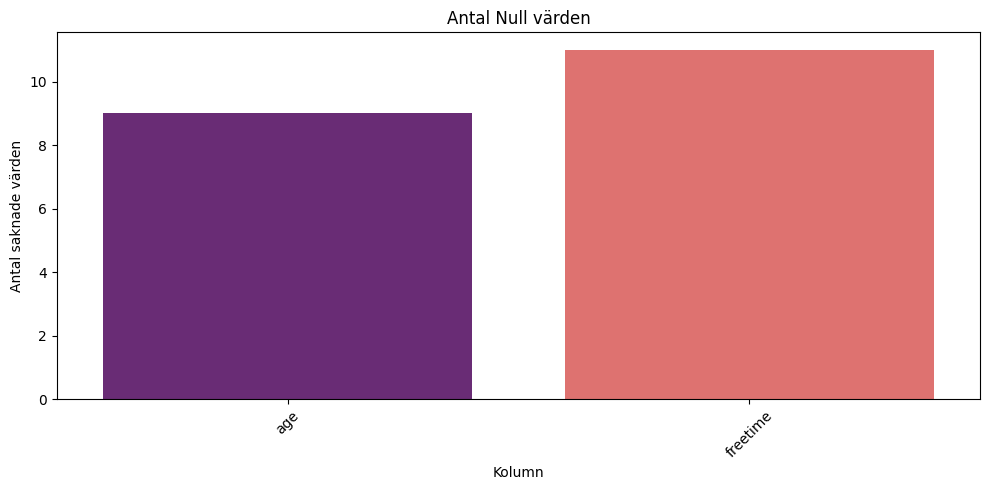

In [65]:
#Uppgift 2A

df_clean = df[df.isnull().sum(axis=1) <=1]
plot_missing_values(df_clean)

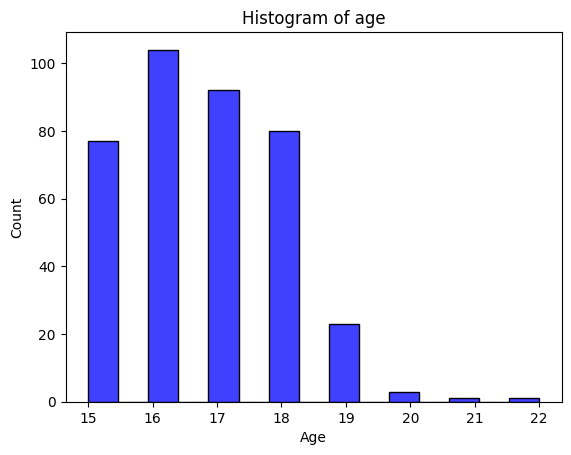

In [ ]:
#Uppgift 2B

sns.histplot(data=df_clean, x="age", color="blue", bins=15)
plt.title("Histogram of age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [ ]:
#Uppgift 2C

print(df_clean.columns)

Index(['Unnamed: 0', 'school', 'sex', 'age', 'address', 'famsize', 'Pstatus',
       'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [82]:
#Uppgift 2D

print(df_clean["higher"].unique())

['yes' 'no']


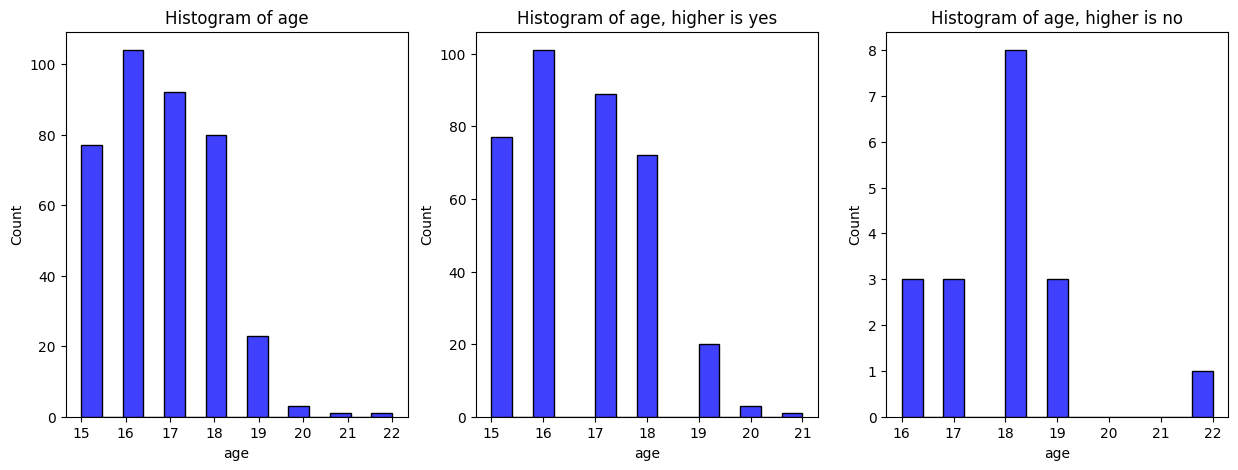

In [91]:
#Uppgift 2E


fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.histplot(data=df_clean, x="age", color="blue", bins=15, ax=axes[0])
axes[0].set_title("Histogram of age")
sns.histplot(data=df_clean[df_clean["higher"] == "yes"], x="age", color="blue", bins=15, ax=axes[1])
axes[1].set_title("Histogram of age, higher is yes")
sns.histplot(data=df_clean[df_clean["higher"] == "no"], x="age", color="blue", bins=15, ax=axes[2])
axes[2].set_title("Histogram of age, higher is no")
plt.show()



In [95]:
# Uppgift 3F

df_clean["Alcohol"] = df_clean["Dalc"] + df_clean["Walc"]

print(df_clean["Alcohol"])


0      2
1      2
2      5
3      2
4      3
      ..
390    9
391    7
392    6
393    7
394    6
Name: Alcohol, Length: 390, dtype: int64


C:\Users\adamh\AppData\Local\Temp\ipykernel_18544\1324584491.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Alcohol"] = df_clean["Dalc"] + df_clean["Walc"]


C:\Users\adamh\AppData\Local\Temp\ipykernel_18544\1904245893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="age", y="Alcohol", palette="cool")


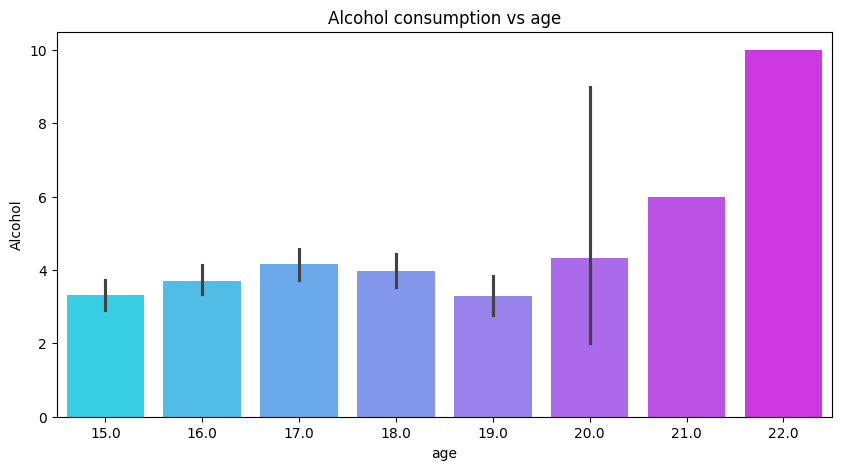

In [98]:
# Uppgift 2G

plt.figure(figsize=(10,5))
sns.barplot(data=df_clean, x="age", y="Alcohol", palette="cool")
plt.title("Alcohol consumption vs age")
plt.show()

---
## 3. Clean freetime column (**)

Now there are missing data on freetime that needs to be filled. 
- Try yourself and find reasonable approaches for how you would fill those missing data.
- Document what you have tried and different findings
- Combine suitable visualizations with pandas methods

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---